# Versão 3 — Ridge + log1p(target)

Prevê **quantos dias a entrega irá atrasar**, treinando somente com pedidos atrasados (`delay_days > 0`).

Combina a transformação `log1p(delay_days)` com regularização **Ridge (L2)**. O `alpha` é escolhido somente com dados de treino usando `TimeSeriesSplit`, preservando a ordem temporal. As métricas finais são calculadas em dias após `expm1`.


In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


In [2]:
# Leitura da MESMA base usada pelo XGBoost
csv_path = Path("../../tabela_final/table_orders_holidays_ecommerce_events.csv")
df = pd.read_csv(csv_path)

# Datas necessárias para engenharia de features, split e criação do target
date_cols = [
    "order_purchase_timestamp",
    "order_estimated_delivery_date",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
]
for col in date_cols:
    if col not in df.columns:
        raise ValueError(f"Coluna obrigatória não encontrada: {col}")
    df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

# ================================================================
# TARGET: QUANTOS DIAS A ENTREGA ATRASOU
# ================================================================
# Usa horas para preservar atrasos fracionários e converte para dias.
df["delay_days"] = (
    (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"])
    .dt.total_seconds() / 86400
)

# A regressão responde: SE ATRASAR, quantos dias irá atrasar?
# Portanto, somente pedidos realmente atrasados entram neste modelo.
df = df[df["delay_days"] > 0].copy()

# ================================================================
# MESMA ENGENHARIA DE FEATURES DO XGBOOST
# ================================================================
df["prazo_transportadora_dias"] = (
    df["order_estimated_delivery_date"] - df["order_delivered_carrier_date"]
).dt.days

df = df.dropna(subset=["prazo_transportadora_dias", "delay_days"]).copy()

df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["prazo_por_km"] = df["prazo_transportadora_dias"] / (df["distance_km"] + 1)
df["frete_por_kg"] = df["freight_value"] / (df["product_weight_g"] / 1000 + 0.1)
df["densidade_produto"] = df["product_weight_g"] / (df["volume_cm3"] + 1)

# Mesmo critério temporal do XGBoost
df = df.sort_values("order_delivered_carrier_date").reset_index(drop=True)
date_col = df["order_delivered_carrier_date"].copy()
split_date = pd.to_datetime("2018-07-01", utc=True)

print(f"Pedidos atrasados disponíveis para regressão: {len(df):,}")
print(f"Atraso médio: {df['delay_days'].mean():.2f} dias")
print(f"Mediana do atraso: {df['delay_days'].median():.2f} dias")
print(f"Menor atraso: {df['delay_days'].min():.2f} dias")
print(f"Maior atraso: {df['delay_days'].max():.2f} dias")


Pedidos atrasados disponíveis para regressão: 2,038
Atraso médio: 6.22 dias
Mediana do atraso: 3.58 dias
Menor atraso: 0.00 dias
Maior atraso: 161.78 dias


In [3]:
# Features: mesmas regras de exclusão do XGBoost, adaptadas ao novo target.
# IMPORTANTE: order_delivered_customer_date e delay_days NUNCA entram em X.

target_col = "delay_days"

leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",  # usada para construir o target
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()
y = df[target_col].copy()

colunas_remover = [
    "order_purchase_timestamp",
    "order_approved_at",
    "interval_code_delivered_carrier",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "delivered_on_time",
    "review_score",
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "holiday_at_purchase",
    "is_weekend",
]
X = X.drop(columns=colunas_remover, errors="ignore")

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print(f"Treino (atrasados até Jun/2018): {len(X_train):,}")
print(f"Teste  (atrasados Jul/2018+):     {len(X_test):,}")
print(f"Features antes do encoding: {X_train.shape[1]}")


Treino (atrasados até Jun/2018): 1,425
Teste  (atrasados Jul/2018+):     613
Features antes do encoding: 26


In [4]:
# Target Encoding suavizado usando APENAS o conjunto de treino.
# Para a regressão, o encoding representa a média suavizada de DIAS DE ATRASO.

media_global_atraso_dias = y_train.mean()
m = 10
encoding_maps = {}

def target_encode_regressao(Xtr, Xte, ytr, coluna, nova_coluna):
    tr_cat = Xtr[coluna].fillna("Unknown").astype(str)
    te_cat = Xte[coluna].fillna("Unknown").astype(str)

    stats = pd.DataFrame({"categoria": tr_cat, "target": ytr.values}) \
        .groupby("categoria")["target"].agg(["count", "mean"])
    smooth = (stats["count"] * stats["mean"] + m * media_global_atraso_dias) / (stats["count"] + m)

    Xtr[nova_coluna] = tr_cat.map(smooth).fillna(media_global_atraso_dias)
    Xte[nova_coluna] = te_cat.map(smooth).fillna(media_global_atraso_dias)
    return smooth

for original, nova in [
    ("customer_city", "customer_city_encoded"),
    ("seller_city", "seller_city_encoded"),
    ("category_name", "category_name_encoded"),
]:
    if original in X_train.columns:
        encoding_maps[original] = target_encode_regressao(X_train, X_test, y_train, original, nova)

cat_originais = [c for c in ["customer_city", "seller_city", "category_name"] if c in X_train.columns]
X_train = X_train.drop(columns=cat_originais)
X_test = X_test.drop(columns=cat_originais)

# Garante somente features numéricas
nao_numericas = X_train.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()
if nao_numericas:
    print("Colunas não numéricas removidas:", nao_numericas)
    X_train = X_train.drop(columns=nao_numericas)
    X_test = X_test.drop(columns=nao_numericas, errors="ignore")

# Infinitos -> NaN; imputação baseada SOMENTE no treino
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

# Mesma normalização usada no pipeline do XGBoost
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print(f"Features finais: {X_train_scaled.shape[1]}")
display(X_train_scaled.head())


Features finais: 26


,holiday_at_carrier,days_since_last_holiday,days_until_next_holiday,ecommerce_event_at_carrier,days_since_last_ecommerce_event,days_until_next_ecommerce_event,is_ecommerce_event_in_7_days,is_ecommerce_event_in_14_days,had_ecommerce_event_7_days_ago,had_ecommerce_event_14_days_ago,purchase_hour,purchase_day_of_week,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city,prazo_transportadora_dias,purchase_month,prazo_por_km,frete_por_kg,densidade_produto,customer_city_encoded,seller_city_encoded,category_name_encoded
0,-0.0265,0.1791,-0.0588,-0.0922,-1.0942,-0.9958,-0.2991,-0.4146,-0.3839,1.7104,1.1596,-0.4324,-0.2249,-0.2081,-0.4094,-0.5519,0.9979,-0.3826,-2.7233,1.2175,-0.5058,-0.1550,-0.0663,-0.2885,1.3126,-0.6279
1,-0.0265,-0.8261,2.3039,-0.0922,-0.8815,2.2575,-0.2991,-0.4146,-0.3839,-0.5846,-2.8131,1.7015,-0.4421,0.0537,4.6263,0.5502,-0.3636,-0.3826,3.2378,-1.3264,0.5198,-1.1473,1.0455,-0.2885,-0.3808,-0.7817
2,-0.0265,-0.1560,1.6521,-0.0922,-0.6687,2.0096,-0.2991,-0.4146,-0.3839,-0.5846,-1.2997,0.1011,-0.4115,-0.1975,-0.4014,0.0887,-0.5297,-0.3826,2.1201,-1.3264,0.4620,-0.1834,-0.3498,-0.5834,-0.5966,1.3430
3,-0.0265,0.5980,0.9188,-0.0922,-0.4294,1.7307,-0.2991,-0.4146,-0.3839,-0.5846,0.5921,0.6346,0.6113,0.0390,-0.3143,-0.4315,1.0572,-0.3826,1.7476,-1.3264,-0.1673,-0.3678,-0.0977,-0.2885,1.3126,0.1872
4,-0.0265,0.9331,0.5929,-0.0922,-0.3230,1.6068,-0.2991,-0.4146,-0.3839,-0.5846,-0.3538,-1.4994,-0.2315,1.1241,-0.1435,-0.2533,0.9271,-0.3826,3.2378,-1.3264,-0.0353,-0.4211,-0.0951,-0.2885,1.3126,0.1872


In [5]:
# Ridge + log1p(target)
# O alpha é selecionado SOMENTE no treino com validação temporal.
y_train_log = np.log1p(y_train)

tscv = TimeSeriesSplit(n_splits=5)
param_grid = {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}

busca_ridge = GridSearchCV(
    Ridge(),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
)
busca_ridge.fit(X_train_scaled, y_train_log)
modelo = busca_ridge.best_estimator_

print(f"Melhor alpha: {busca_ridge.best_params_['alpha']}")

y_pred_train_log = modelo.predict(X_train_scaled)
y_pred_test_log = modelo.predict(X_test_scaled)
y_pred_train = np.expm1(y_pred_train_log)
y_pred_test = np.expm1(y_pred_test_log)

y_pred_train_operacional = np.maximum(y_pred_train, 0)
y_pred_test_operacional = np.maximum(y_pred_test, 0)

print("Ridge + log1p(target) treinado com sucesso.")


Melhor alpha: 100.0
Ridge + log1p(target) treinado com sucesso.


In [6]:
# Métricas de regressão
def metricas_regressao(y_true, y_pred):
    return {
        "R²": r2_score(y_true, y_pred),
        "MAE (dias)": mean_absolute_error(y_true, y_pred),
        "RMSE (dias)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (%)": mean_absolute_percentage_error(y_true, y_pred) * 100,
    }

metricas = pd.DataFrame({
    "Treino": metricas_regressao(y_train, y_pred_train_operacional),
    "Teste": metricas_regressao(y_test, y_pred_test_operacional),
}).T

display(metricas.round(4))

print(f"\nInterpretação principal: no teste, o modelo erra em média {metricas.loc['Teste', 'MAE (dias)']:.2f} dias.")
print(f"RMSE no teste: {metricas.loc['Teste', 'RMSE (dias)']:.2f} dias.")
print(f"R² no teste: {metricas.loc['Teste', 'R²']:.4f}.")


,R²,MAE (dias),RMSE (dias),MAPE (%)
Treino,0.1188,5.2501,11.7824,300.8363
Teste,-0.0654,3.3847,4.8717,862.4391



Interpretação principal: no teste, o modelo erra em média 3.38 dias.
RMSE no teste: 4.87 dias.
R² no teste: -0.0654.


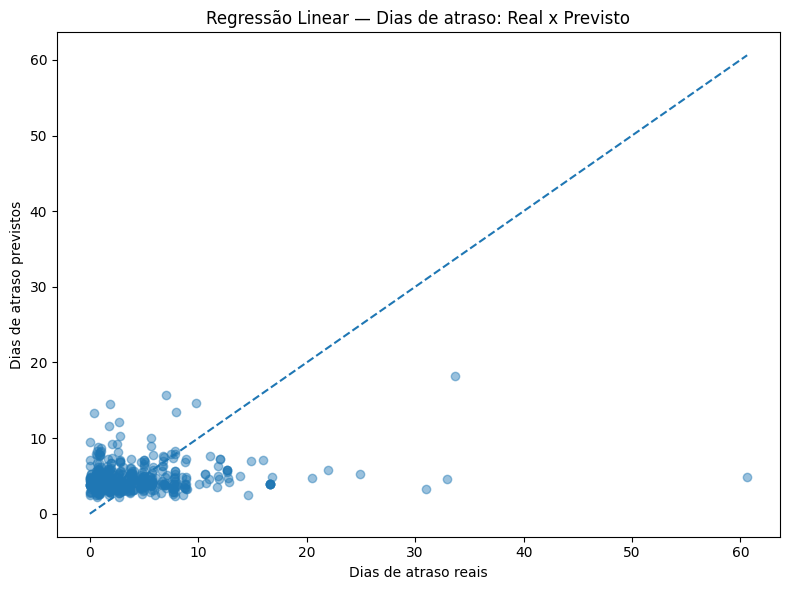

In [7]:
# Comparação Real x Previsto no conjunto de teste
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_operacional, alpha=0.45)
lim_max = max(float(y_test.max()), float(y_pred_test_operacional.max()))
plt.plot([0, lim_max], [0, lim_max], linestyle="--")
plt.xlabel("Dias de atraso reais")
plt.ylabel("Dias de atraso previstos")
plt.title("Regressão Linear — Dias de atraso: Real x Previsto")
plt.tight_layout()
plt.show()


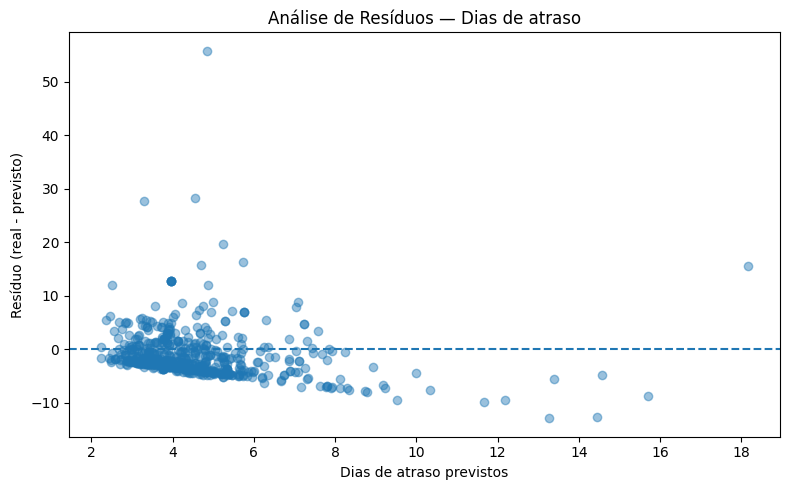

In [8]:
# Resíduos no teste
residuos = y_test.values - y_pred_test_operacional
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test_operacional, residuos, alpha=0.45)
plt.axhline(0, linestyle="--")
plt.xlabel("Dias de atraso previstos")
plt.ylabel("Resíduo (real - previsto)")
plt.title("Análise de Resíduos — Dias de atraso")
plt.tight_layout()
plt.show()


,feature,coeficiente_log,abs_coef
23,customer_city_encoded,0.1524,0.1524
24,seller_city_encoded,0.1294,0.1294
9,had_ecommerce_event_14_days_ago,-0.0939,0.0939
21,frete_por_kg,0.0923,0.0923
25,category_name_encoded,0.0847,0.0847
13,freight_value,0.0827,0.0827
18,prazo_transportadora_dias,-0.0731,0.0731
8,had_ecommerce_event_7_days_ago,0.0597,0.0597
4,days_since_last_ecommerce_event,-0.0545,0.0545
5,days_until_next_ecommerce_event,0.0525,0.0525


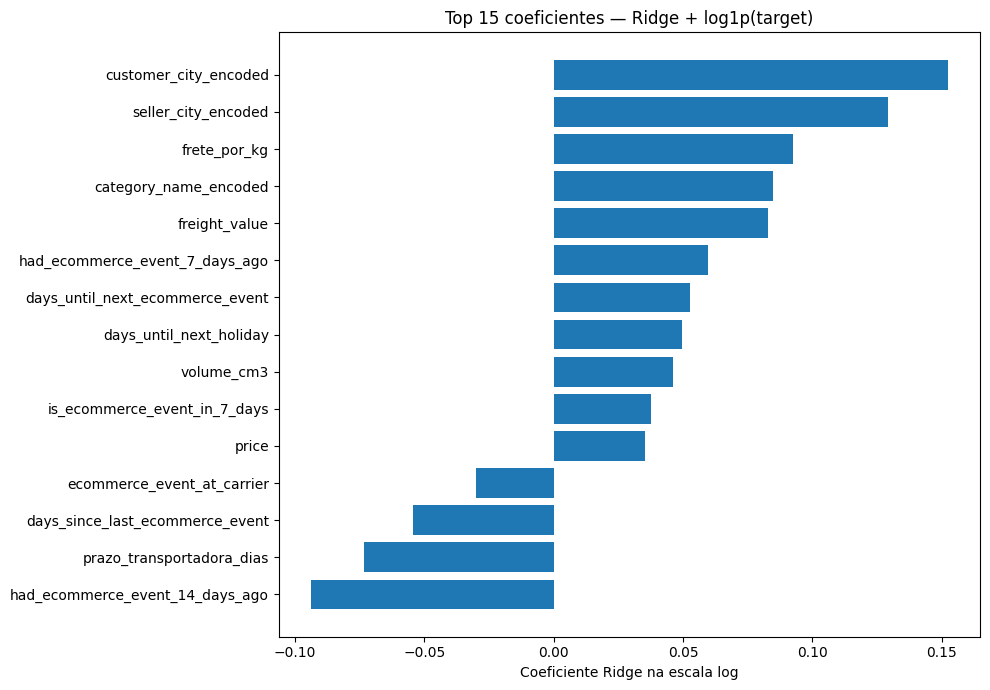

In [9]:
# Coeficientes do Ridge na escala logarítmica do target
coeficientes = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coeficiente_log": modelo.coef_,
})
coeficientes["abs_coef"] = coeficientes["coeficiente_log"].abs()
coeficientes = coeficientes.sort_values("abs_coef", ascending=False)
display(coeficientes.head(20))

plt.figure(figsize=(10, 7))
top = coeficientes.head(15).sort_values("coeficiente_log")
plt.barh(top["feature"], top["coeficiente_log"])
plt.xlabel("Coeficiente Ridge na escala log")
plt.title("Top 15 coeficientes — Ridge + log1p(target)")
plt.tight_layout()
plt.show()


In [10]:
# Exemplo das previsões do teste
resultado_teste = pd.DataFrame({
    "dias_atraso_real": y_test.values,
    "dias_atraso_previsto": y_pred_test_operacional,
})
resultado_teste["erro_absoluto_dias"] = (
    resultado_teste["dias_atraso_real"] - resultado_teste["dias_atraso_previsto"]
).abs()

display(resultado_teste.head(20).round(2))


,dias_atraso_real,dias_atraso_previsto,erro_absoluto_dias
0,0.8000,3.8700,3.0700
1,0.8300,4.1100,3.2800
2,0.8300,4.1100,3.2800
3,0.6500,4.7700,4.1100
4,7.7800,3.2400,4.5400
5,11.8400,4.9400,6.9000
6,60.6100,4.8400,55.7700
7,0.7400,4.5000,3.7600
8,7.9000,3.7200,4.1800
9,31.0000,3.3000,27.7000


In [11]:
# Exportação do Ridge + pré-processamento
artefato_modelo = {
    "model": modelo,
    "best_alpha": modelo.alpha,
    "scaler": scaler,
    "feature_columns": list(X_train_scaled.columns),
    "target": "delay_days",
    "target_transform": "log1p",
    "inverse_target_transform": "expm1",
    "training_scope": "somente pedidos com delay_days > 0",
    "target_encoding_maps": encoding_maps,
    "target_encoding_global_mean": media_global_atraso_dias,
    "target_encoding_smoothing_m": m,
    "train_medians": train_medians,
    "split_date": split_date,
    "clip_prediction_min_zero": True,
}

nome_arquivo_modelo = "ridge_log_dias_atraso.pkl"
with open(nome_arquivo_modelo, "wb") as file:
    pickle.dump(artefato_modelo, file)
print(f"Modelo salvo: {nome_arquivo_modelo}")

n_registros = 100
df_export = X_test_scaled.head(n_registros).copy()
df_export["delay_days_real"] = y_test.head(n_registros).values
df_export["delay_days_previsto"] = y_pred_test_operacional[:n_registros].round(4)
nome_csv = f"amostra_ridge_log_atraso_{n_registros}_pedidos.csv"
df_export.to_csv(nome_csv, index=False)
print(f"Amostra salva: {nome_csv}")


Modelo salvo: ridge_log_dias_atraso.pkl
Amostra salva: amostra_ridge_log_atraso_100_pedidos.csv


## Observação metodológica importante

A variável `delay_days` utiliza a **data real de entrega apenas para criar o rótulo (target) histórico**, o que é correto durante o treinamento supervisionado. Essa data não é fornecida ao modelo como feature.

Este notebook replica as features do XGBoost de referência, inclusive `prazo_transportadora_dias`, calculada a partir de `order_delivered_carrier_date`. Se a previsão de produção precisar acontecer estritamente **no momento da compra**, essa feature e o próprio critério temporal baseado na coleta pela transportadora devem ser revistos em ambos os modelos para que somente informações disponíveis naquele instante sejam utilizadas.
